In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
# ============================================================
# LOAD PROCESSED DATASETS
# ============================================================

cln1 = pd.read_csv("../data/processed/cln1_processed.csv")

cln2 = pd.read_csv("../data/processed/cln2_processed.csv")

cln3 = pd.read_csv("../data/processed/cln3_processed.csv")


print("=" * 60)
print("CLN1")
print("=" * 60)
print(cln1.shape)


print("\n" + "=" * 60)
print("CLN2")
print("=" * 60)
print(cln2.shape)


print("\n" + "=" * 60)
print("CLN3")
print("=" * 60)
print(cln3.shape)

CLN1
(385, 31)

CLN2
(924, 36)

CLN3
(498, 36)


In [3]:
# ============================================================
# CHECK DATASET COLUMNS
# ============================================================

print("=" * 70)
print("CLN1 COLUMNS")
print("=" * 70)

print(cln1.columns.tolist())


print("\n" + "=" * 70)
print("CLN2 COLUMNS")
print("=" * 70)

print(cln2.columns.tolist())


print("\n" + "=" * 70)
print("CLN3 COLUMNS")
print("=" * 70)

print(cln3.columns.tolist())

CLN1 COLUMNS
['Patient ID', 'REL #', 'Patient ID2', 'Mutation #', 'Alleles', 'Changes in same gene', 'Changes in other genes', 'NCL Phenotype or other disease', 'Age at onset (y)', 'Histology', 'Country of origin', 'other ethnic detail', 'Country of Residence', 'Reference', 'PMID_patient', 'Notes', 'Identifier', 'Location', 'Nucleotide change', 'Amino acid change', 'Type of Mutation - DNA', 'Additional mutation information', 'Predicted functional effect', 'clinvar classification', 'rs number', 'contig position (GRCh38.p7)', 'PMID_mutation', 'References', 'Original description', 'Others notes', 'Disease_Subtype']

CLN2 COLUMNS
['Patient identifer', 'REL#', 'Other Patient ID', 'Mutation_ID', 'Allele', 'Changes in the same gene', 'Changes in other genes', 'NCL Phenotype or other disease', 'Age of onset (y)', 'Histology', 'Country of origin', 'other ethnic detail', 'Country of residence', 'Reference_patient', 'PMID_patient', 'Notes_patient', 'Notes2', 'Notes3', 'Notes4', 'Notes5', 'Locatio

In [4]:
# ============================================================
# STANDARDIZE CLN1 COLUMN NAMES
# ============================================================

cln1 = cln1.rename(columns={

    "Patient ID": "Patient_ID",

    "Mutation #": "Mutation_ID",

    "Alleles": "Allele",

    "NCL Phenotype or other disease": "Phenotype",

    "Age at onset (y)": "Age_Onset",

    "Country of origin": "Country"
})


# ============================================================
# STANDARDIZE CLN2 COLUMN NAMES
# ============================================================

cln2 = cln2.rename(columns={

    "Patient identifer": "Patient_ID",

    "mutation number": "Mutation_ID",

    "Allele": "Allele",

    "NCL Phenotype or other disease": "Phenotype",

    "Age of onset (y)": "Age_Onset",

    "Country of origin": "Country"
})


# ============================================================
# STANDARDIZE CLN3 COLUMN NAMES
# ============================================================

cln3 = cln3.rename(columns={

    "DB Patient ID": "Patient_ID",

    "mutation number": "Mutation_ID",

    "allele": "Allele",

    "NCL phenotype or other disease": "Phenotype",

    "Age at onset (y)": "Age_Onset",

    "Country of origin": "Country"
})


print("Column standardization completed!")

Column standardization completed!


In [5]:
# ============================================================
# SELECT COMMON CLINICAL FEATURES
# ============================================================

selected_columns = [

    "Patient_ID",

    "Mutation_ID",

    "Allele",

    "Phenotype",

    "Age_Onset",

    "Country",

    "Disease_Subtype"
]


# Ensure all required columns exist

for dataset_name, dataset in {

    "CLN1": cln1,

    "CLN2": cln2,

    "CLN3": cln3

}.items():

    print(
        dataset_name,
        "available columns:"
    )

    print(
        [
            col
            for col in selected_columns
            if col in dataset.columns
        ]
    )

CLN1 available columns:
['Patient_ID', 'Mutation_ID', 'Allele', 'Phenotype', 'Age_Onset', 'Country', 'Disease_Subtype']
CLN2 available columns:
['Patient_ID', 'Mutation_ID', 'Allele', 'Phenotype', 'Age_Onset', 'Country', 'Disease_Subtype']
CLN3 available columns:
['Patient_ID', 'Mutation_ID', 'Allele', 'Phenotype', 'Age_Onset', 'Country', 'Disease_Subtype']


In [6]:
# ============================================================
# CREATE COMMON DATASETS SAFELY
# ============================================================

def select_common_columns(df, columns):

    for column in columns:

        if column not in df.columns:

            df[column] = np.nan

    return df[columns].copy()


cln1_final = select_common_columns(
    cln1,
    selected_columns
)

cln2_final = select_common_columns(
    cln2,
    selected_columns
)

cln3_final = select_common_columns(
    cln3,
    selected_columns
)


print("CLN1 Final Shape:", cln1_final.shape)

print("CLN2 Final Shape:", cln2_final.shape)

print("CLN3 Final Shape:", cln3_final.shape)

CLN1 Final Shape: (385, 7)
CLN2 Final Shape: (924, 7)
CLN3 Final Shape: (498, 7)


In [7]:
# ============================================================
# COMBINE ALL BATTEN DISEASE DATASETS
# ============================================================

batten_dataset = pd.concat(

    [
        cln1_final,

        cln2_final,

        cln3_final
    ],

    ignore_index=True
)


print("=" * 60)

print("FINAL COMBINED DATASET")

print("=" * 60)

print("\nDataset Shape:")

print(batten_dataset.shape)


print("\nDisease Subtype Distribution:")

print(
    batten_dataset[
        "Disease_Subtype"
    ].value_counts()
)

FINAL COMBINED DATASET

Dataset Shape:
(1807, 7)

Disease Subtype Distribution:
Disease_Subtype
CLN2    924
CLN3    498
CLN1    385
Name: count, dtype: int64


In [8]:
# ============================================================
# REMOVE DUPLICATES
# ============================================================

print(
    "Before removing duplicates:",
    len(batten_dataset)
)


batten_dataset = (

    batten_dataset
    .drop_duplicates()
    .copy()
)


print(
    "After removing duplicates:",
    len(batten_dataset)
)


print(
    "Remaining duplicates:",
    batten_dataset
    .duplicated()
    .sum()
)

Before removing duplicates: 1807
After removing duplicates: 1764
Remaining duplicates: 0


In [9]:
# ============================================================
# FINAL DATASET INSPECTION
# ============================================================

print("=" * 60)

print("FINAL DATASET INFORMATION")

print("=" * 60)


print("\nTotal Records:")

print(
    len(batten_dataset)
)


print("\nColumns:")

print(
    batten_dataset.columns.tolist()
)


print("\nMissing Values:")

print(
    batten_dataset
    .isnull()
    .sum()
)


print("\nDisease Subtypes:")

print(
    batten_dataset[
        "Disease_Subtype"
    ]
    .value_counts()
)


print("\nSample Records:")

display(
    batten_dataset.head(10)
)

FINAL DATASET INFORMATION

Total Records:
1764

Columns:
['Patient_ID', 'Mutation_ID', 'Allele', 'Phenotype', 'Age_Onset', 'Country', 'Disease_Subtype']

Missing Values:
Patient_ID           2
Mutation_ID        161
Allele              72
Phenotype          494
Age_Onset          885
Country            240
Disease_Subtype      0
dtype: int64

Disease Subtypes:
Disease_Subtype
CLN2    905
CLN3    481
CLN1    378
Name: count, dtype: int64

Sample Records:


,Patient_ID,Mutation_ID,Allele,Phenotype,Age_Onset,Country,Disease_Subtype
0,Pa-cln1.001,cln1.001,p.Arg122Trp,infantile,NaN,Finland,CLN1
1,Pa-cln1.002,cln1.001,p.Arg122Trp,infantile,NaN,Finland,CLN1
2,Pa-cln1.003,cln1.001,p.Arg122Trp,infantile,NaN,Finland,CLN1
3,Pa-cln1.004,cln1.001,p.Arg122Trp,infantile,NaN,Finland,CLN1
4,Pa-cln1.005,cln1.001,p.Arg122Trp,infantile,NaN,Finland,CLN1
5,Pa-cln1.006,cln1.001,p.Arg122Trp,infantile,NaN,Finland,CLN1
6,Pa-cln1.007,cln1.001,p.Arg122Trp,infantile,NaN,Finland,CLN1
7,Pa-cln1.008,cln1.001,p.Arg122Trp,infantile,NaN,Finland,CLN1
8,Pa-cln1.009,cln1.001,p.Arg122Trp,infantile,NaN,Finland,CLN1
9,Pa-cln1.010,cln1.001,p.Arg122Trp,infantile,NaN,Finland,CLN1


In [10]:
# ============================================================
# SAVE FINAL COMBINED DATASET
# ============================================================

os.makedirs(
    "../data/final",
    exist_ok=True
)


batten_dataset.to_csv(

    "../data/final/batten_combined_dataset.csv",

    index=False
)


print("SUCCESS!")

print(
    "Final dataset saved at:"
)

print(
    "../data/final/batten_combined_dataset.csv"
)

SUCCESS!
Final dataset saved at:
../data/final/batten_combined_dataset.csv


In [11]:
import pandas as pd
import os

processed_path = "../data/processed"

print("Files inside processed folder:")
print(os.listdir(processed_path))

Files inside processed folder:
['cln1_processed.csv', 'cln2_processed.csv', 'cln3_processed.csv', 'README.md']


In [12]:
cln1 = pd.read_csv("../data/processed/cln1_processed.csv")
cln2 = pd.read_csv("../data/processed/cln2_processed.csv")
cln3 = pd.read_csv("../data/processed/cln3_processed.csv")

print("CLN1 Shape:", cln1.shape)
print("CLN2 Shape:", cln2.shape)
print("CLN3 Shape:", cln3.shape)

CLN1 Shape: (385, 31)
CLN2 Shape: (924, 36)
CLN3 Shape: (498, 36)


In [13]:
print("CLN1 labels:")
print(cln1["Disease_Subtype"].value_counts())

print("\nCLN2 labels:")
print(cln2["Disease_Subtype"].value_counts())

print("\nCLN3 labels:")
print(cln3["Disease_Subtype"].value_counts())

CLN1 labels:
Disease_Subtype
CLN1    385
Name: count, dtype: int64

CLN2 labels:
Disease_Subtype
CLN2    924
Name: count, dtype: int64

CLN3 labels:
Disease_Subtype
CLN3    498
Name: count, dtype: int64


In [14]:
print("CLN1 columns:", len(cln1.columns))
print("CLN2 columns:", len(cln2.columns))
print("CLN3 columns:", len(cln3.columns))

common_columns = list(
    set(cln1.columns)
    .intersection(set(cln2.columns))
    .intersection(set(cln3.columns))
)

print("\nNumber of common columns:", len(common_columns))

print("\nCommon columns:")
for col in sorted(common_columns):
    print(col)

CLN1 columns: 31
CLN2 columns: 36
CLN3 columns: 36

Number of common columns: 13

Common columns:
Amino acid change
Changes in other genes
Country of origin
Disease_Subtype
Histology
Location
Nucleotide change
Original description
PMID_mutation
PMID_patient
Type of Mutation - DNA
clinvar classification
rs number


In [15]:
clinical_features = [
    "NCL Phenotype or other disease",
    "Age at onset (y)",
    "Histology",
    "Country of origin",
    "Disease_Subtype"
]

available_features = []

for col in clinical_features:
    if col in cln1.columns and col in cln2.columns and col in cln3.columns:
        available_features.append(col)

print("Available clinical features:")
print(available_features)

Available clinical features:
['Histology', 'Country of origin', 'Disease_Subtype']


In [16]:
def standardize_columns(df):
    
    rename_dict = {
        
        # Age
        "Age of onset (y)": "Age_at_onset",
        "Age at onset (y)": "Age_at_onset",
        
        # Phenotype
        "NCL Phenotype or other disease": "Phenotype",
        "NCL phenotype or other disease": "Phenotype",
        
        # Histology
        "Histology": "Histology",
        
        # Country
        "Country of origin": "Country_of_origin",
        
        # Mutation
        "Mutation #": "Mutation_ID",
        "mutation number": "Mutation_ID",
        
        # Alleles
        "Alleles": "Allele",
        "Allele": "Allele",
        "allele": "Allele"
    }
    
    df = df.rename(columns=rename_dict)
    
    return df


cln1 = standardize_columns(cln1)
cln2 = standardize_columns(cln2)
cln3 = standardize_columns(cln3)

print("Column standardization completed.")

Column standardization completed.


In [17]:
final_columns = [
    "Phenotype",
    "Age_at_onset",
    "Histology",
    "Country_of_origin",
    "Mutation_ID",
    "Allele",
    "Disease_Subtype"
]

final_columns = [
    col for col in final_columns
    if col in cln1.columns
    and col in cln2.columns
    and col in cln3.columns
]

print("Final columns available:")
print(final_columns)

Final columns available:
['Phenotype', 'Age_at_onset', 'Histology', 'Country_of_origin', 'Mutation_ID', 'Allele', 'Disease_Subtype']


In [18]:
cln1_final = cln1[final_columns].copy()
cln2_final = cln2[final_columns].copy()
cln3_final = cln3[final_columns].copy()

combined_data = pd.concat(
    [cln1_final, cln2_final, cln3_final],
    ignore_index=True
)

print("Combined Dataset Shape:", combined_data.shape)

print("\nDisease Distribution:")
print(combined_data["Disease_Subtype"].value_counts())

print("\nFirst 5 rows:")
display(combined_data.head())

Combined Dataset Shape: (1807, 7)

Disease Distribution:
Disease_Subtype
CLN2    924
CLN3    498
CLN1    385
Name: count, dtype: int64

First 5 rows:


,Phenotype,Age_at_onset,Histology,Country_of_origin,Mutation_ID,Allele,Disease_Subtype
0,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1
1,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1
2,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1
3,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1
4,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1


In [19]:
combined_data.to_csv(
    "../data/processed/batten_combined_dataset.csv",
    index=False
)

print("Combined dataset saved successfully!")

print(
    "../data/processed/batten_combined_dataset.csv"
)

Combined dataset saved successfully!
../data/processed/batten_combined_dataset.csv


In [20]:
import pandas as pd
import numpy as np

data = pd.read_csv("../data/processed/batten_combined_dataset.csv")

print("Dataset Shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())

print("\nDisease Distribution:")
print(data["Disease_Subtype"].value_counts())

display(data.head())

Dataset Shape: (1807, 7)

Columns:
['Phenotype', 'Age_at_onset', 'Histology', 'Country_of_origin', 'Mutation_ID', 'Allele', 'Disease_Subtype']

Disease Distribution:
Disease_Subtype
CLN2    924
CLN3    498
CLN1    385
Name: count, dtype: int64


,Phenotype,Age_at_onset,Histology,Country_of_origin,Mutation_ID,Allele,Disease_Subtype
0,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1
1,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1
2,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1
3,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1
4,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1


In [21]:
print("Missing Values:\n")

missing_values = data.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ].sort_values(ascending=False)
)

Missing Values:

Histology            1320
Age_at_onset          911
Phenotype             520
Country_of_origin     244
Mutation_ID           170
Allele                 81
dtype: int64


In [22]:
print("Duplicate Rows:", data.duplicated().sum())

data = data.drop_duplicates()

print("Shape After Removing Duplicates:", data.shape)

Duplicate Rows: 576
Shape After Removing Duplicates: (1231, 7)


In [23]:
print(data.columns)

Index(['Phenotype', 'Age_at_onset', 'Histology', 'Country_of_origin',
       'Mutation_ID', 'Allele', 'Disease_Subtype'],
      dtype='str')


In [24]:
data["Age_at_onset"] = pd.to_numeric(
    data["Age_at_onset"],
    errors="coerce"
)

print(data["Age_at_onset"].describe())

count    719.000000
mean       5.528665
std        6.769563
min        0.000000
25%        3.000000
50%        3.500000
75%        6.000000
max       66.000000
Name: Age_at_onset, dtype: float64


In [25]:
data["Age_at_onset"] = data["Age_at_onset"].fillna(
    data["Age_at_onset"].median()
)

In [26]:
categorical_columns = [
    col for col in data.columns
    if data[col].dtype == "object"
    and col != "Disease_Subtype"
]

for col in categorical_columns:
    
    print("\n" + "=" * 60)
    print("COLUMN:", col)
    print("=" * 60)
    
    print("Unique Values:", data[col].nunique())
    
    print(
        data[col]
        .value_counts()
        .head(10)
    )

In [27]:
categorical_columns = [
    "Phenotype",
    "Histology",
    "Country_of_origin",
    "Mutation_ID",
    "Allele"
]

# Keep only columns that actually exist
categorical_columns = [
    col for col in categorical_columns
    if col in data.columns
]

print("Categorical columns used:")
print(categorical_columns)


for col in categorical_columns:
    
    data[col] = data[col].fillna("Unknown")

Categorical columns used:
['Phenotype', 'Histology', 'Country_of_origin', 'Mutation_ID', 'Allele']


In [28]:
feature_columns = [
    "Phenotype",
    "Age_at_onset",
    "Histology",
    "Country_of_origin"
]

feature_columns = [
    col for col in feature_columns
    if col in data.columns
]

target_column = "Disease_Subtype"

print("Features:")
print(feature_columns)

print("\nTarget:")
print(target_column)

Features:
['Phenotype', 'Age_at_onset', 'Histology', 'Country_of_origin']

Target:
Disease_Subtype


In [29]:
X = data[feature_columns].copy()

y = data[target_column].copy()

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

X Shape: (1231, 4)
y Shape: (1231,)

Target Distribution:
Disease_Subtype
CLN2    632
CLN3    334
CLN1    265
Name: count, dtype: int64


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [31]:
numerical_features = [
    col for col in X.columns
    if X[col].dtype != "object"
]

categorical_features = [
    col for col in X.columns
    if X[col].dtype == "object"
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Phenotype', 'Age_at_onset', 'Histology', 'Country_of_origin']

Categorical Features:
[]


In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
        
    ],
    
    remainder="passthrough"
)

In [33]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.20,
    
    random_state=42,
    
    stratify=y
)


print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

print("\nTraining Labels:")
print(y_train.value_counts())

print("\nTesting Labels:")
print(y_test.value_counts())

Training Data Shape: (984, 4)
Testing Data Shape: (247, 4)

Training Labels:
Disease_Subtype
CLN2    505
CLN3    267
CLN1    212
Name: count, dtype: int64

Testing Labels:
Disease_Subtype
CLN2    127
CLN3     67
CLN1     53
Name: count, dtype: int64


In [34]:
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

In [35]:
random_forest_model = Pipeline(
    
    steps=[
        
        (
            "preprocessor",
            preprocessor
        ),
        
        (
            "model",
            
            RandomForestClassifier(
                
                n_estimators=200,
                
                random_state=42,
                
                class_weight="balanced"
                
            )
            
        )
        
    ]
)

In [37]:
print(X.dtypes)

print("\nSample values:")
for col in X.columns:
    print("\nCOLUMN:", col)
    print(X[col].dropna().head(10).tolist())

Phenotype                str
Age_at_onset         float64
Histology                str
Country_of_origin        str
dtype: object

Sample values:

COLUMN: Phenotype
['infantile', 'infantile', 'infantile', 'infantile', 'infantile', 'infantile', 'infantile', 'infantile', 'infantile', 'juvenile']

COLUMN: Age_at_onset
[3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 6.0]

COLUMN: Histology
['Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'GROD']

COLUMN: Country_of_origin
['Finland', 'Finland', 'Germany', 'Estonia', 'Germany', 'Sweden', 'Sweden', 'UK', 'UK', 'England']


In [40]:
if "Age_at_onset" in X.columns:
    
    X["Age_at_onset"] = pd.to_numeric(
        X["Age_at_onset"],
        errors="coerce"
    )
    
    X["Age_at_onset"] = X["Age_at_onset"].fillna(
        X["Age_at_onset"].median()
    )

In [41]:
print(X.dtypes)

Phenotype                str
Age_at_onset         float64
Histology                str
Country_of_origin        str
dtype: object


In [42]:
if "Age_at_onset" in data.columns:

    data["Age_at_onset"] = pd.to_numeric(
        data["Age_at_onset"],
        errors="coerce"
    )

    median_age = data["Age_at_onset"].median()

    data["Age_at_onset"] = data["Age_at_onset"].fillna(
        median_age
    )

print("Age_at_onset processed successfully.")

if "Age_at_onset" in data.columns:
    print(data["Age_at_onset"].describe())

Age_at_onset processed successfully.
count    1231.000000
mean        4.684898
std         5.267981
min         0.000000
25%         3.150000
50%         3.500000
75%         4.000000
max        66.000000
Name: Age_at_onset, dtype: float64


In [43]:
print("DATA TYPES:\n")

print(data.dtypes)

print("\n" + "=" * 60)
print("SAMPLE VALUES FROM EACH COLUMN")
print("=" * 60)

for col in data.columns:

    print("\nCOLUMN:", col)

    print(
        data[col]
        .dropna()
        .head(5)
        .tolist()
    )

DATA TYPES:

Phenotype                str
Age_at_onset         float64
Histology                str
Country_of_origin        str
Mutation_ID              str
Allele                   str
Disease_Subtype          str
dtype: object

SAMPLE VALUES FROM EACH COLUMN

COLUMN: Phenotype
['infantile', 'infantile', 'infantile', 'infantile', 'infantile']

COLUMN: Age_at_onset
[3.5, 3.5, 3.5, 3.5, 3.5]

COLUMN: Histology
['Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown']

COLUMN: Country_of_origin
['Finland', 'Finland', 'Germany', 'Estonia', 'Germany']

COLUMN: Mutation_ID
['cln1.001', 'Unknown', 'cln1.001', 'cln1.001', 'Unknown']

COLUMN: Allele
['p.Arg122Trp', 'null allele', 'p.Arg122Trp', 'p.Arg122Trp', 'not identified']

COLUMN: Disease_Subtype
['CLN1', 'CLN1', 'CLN1', 'CLN1', 'CLN1']


In [44]:
categorical_columns = [
    "Phenotype",
    "Histology",
    "Country_of_origin"
]

# Keep only columns that actually exist
categorical_columns = [
    col
    for col in categorical_columns
    if col in data.columns
]

for col in categorical_columns:

    data[col] = (
        data[col]
        .fillna("Unknown")
        .astype(str)
    )


print("Categorical missing values handled.")

print("\nCategorical Columns:")
print(categorical_columns)

Categorical missing values handled.

Categorical Columns:
['Phenotype', 'Histology', 'Country_of_origin']


In [45]:
feature_columns = []

possible_features = [

    "Phenotype",

    "Age_at_onset",

    "Histology",

    "Country_of_origin"

]


for col in possible_features:

    if col in data.columns:

        feature_columns.append(col)


target_column = "Disease_Subtype"


print("Selected Features:")

print(feature_columns)


print("\nTarget Column:")

print(target_column)

Selected Features:
['Phenotype', 'Age_at_onset', 'Histology', 'Country_of_origin']

Target Column:
Disease_Subtype


In [46]:
X = data[feature_columns].copy()

y = data[target_column].copy()


print("X Shape:", X.shape)

print("y Shape:", y.shape)


print("\nX Data Types:")

print(X.dtypes)


print("\nTarget Distribution:")

print(y.value_counts())

X Shape: (1231, 4)
y Shape: (1231,)

X Data Types:
Phenotype                str
Age_at_onset         float64
Histology                str
Country_of_origin        str
dtype: object

Target Distribution:
Disease_Subtype
CLN2    632
CLN3    334
CLN1    265
Name: count, dtype: int64


In [47]:
numerical_features = []

categorical_features = []


# Explicitly define Age as numerical

if "Age_at_onset" in X.columns:

    X["Age_at_onset"] = pd.to_numeric(

        X["Age_at_onset"],

        errors="coerce"

    )

    X["Age_at_onset"] = X["Age_at_onset"].fillna(

        X["Age_at_onset"].median()

    )

    numerical_features.append(

        "Age_at_onset"

    )


# Explicitly define these as categorical

for col in [

    "Phenotype",

    "Histology",

    "Country_of_origin"

]:

    if col in X.columns:

        X[col] = (

            X[col]

            .fillna("Unknown")

            .astype(str)

        )

        categorical_features.append(col)


print("Numerical Features:")

print(numerical_features)


print("\nCategorical Features:")

print(categorical_features)


print("\nFinal Data Types:")

print(X.dtypes)

Numerical Features:
['Age_at_onset']

Categorical Features:
['Phenotype', 'Histology', 'Country_of_origin']

Final Data Types:
Phenotype                str
Age_at_onset         float64
Histology                str
Country_of_origin        str
dtype: object


In [48]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder


transformers = []


if categorical_features:

    transformers.append(

        (

            "categorical",

            OneHotEncoder(

                handle_unknown="ignore"

            ),

            categorical_features

        )

    )


preprocessor = ColumnTransformer(

    transformers=transformers,

    remainder="passthrough"

)


print("Preprocessor created successfully.")

Preprocessor created successfully.


In [49]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


print("\nTraining Labels:")

print(y_train.value_counts())


print("\nTesting Labels:")

print(y_test.value_counts())

Training Data Shape: (984, 4)
Testing Data Shape: (247, 4)

Training Labels:
Disease_Subtype
CLN2    505
CLN3    267
CLN1    212
Name: count, dtype: int64

Testing Labels:
Disease_Subtype
CLN2    127
CLN3     67
CLN1     53
Name: count, dtype: int64


In [50]:
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier


random_forest_model = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "model",

            RandomForestClassifier(

                n_estimators=200,

                random_state=42,

                class_weight="balanced"

            )

        )

    ]

)


random_forest_model.fit(

    X_train,

    y_train

)


print(

    "Random Forest Model Training Completed Successfully!"

)

Random Forest Model Training Completed Successfully!


In [51]:
y_pred_rf = random_forest_model.predict(

    X_test

)

print(

    "Predictions Generated Successfully!"

)

Predictions Generated Successfully!


In [52]:
from sklearn.metrics import (

    accuracy_score,

    classification_report

)


rf_accuracy = accuracy_score(

    y_test,

    y_pred_rf

)


print(

    "Random Forest Accuracy:",

    round(

        rf_accuracy * 100,

        2

    ),

    "%"

)


print(

    "\nClassification Report:\n"

)


print(

    classification_report(

        y_test,

        y_pred_rf

    )

)

Random Forest Accuracy: 83.81 %

Classification Report:

              precision    recall  f1-score   support

        CLN1       0.77      0.75      0.76        53
        CLN2       0.96      0.84      0.90       127
        CLN3       0.72      0.90      0.80        67

    accuracy                           0.84       247
   macro avg       0.82      0.83      0.82       247
weighted avg       0.85      0.84      0.84       247



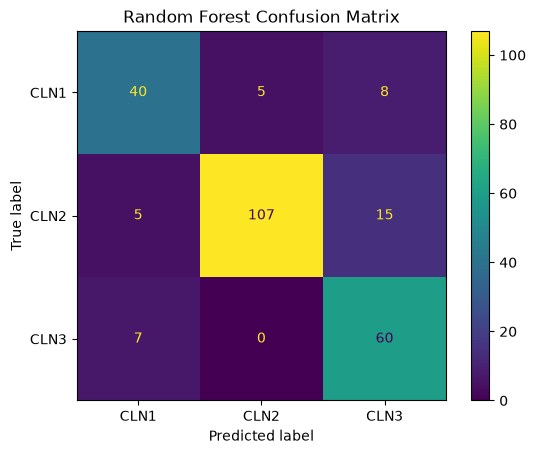

In [53]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred_rf

)


plt.title(

    "Random Forest Confusion Matrix"

)


plt.show()

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

decision_tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree Model Training Completed Successfully!")

Decision Tree Model Training Completed Successfully!


In [55]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_dt = decision_tree_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

Decision Tree Accuracy: 80.57 %

Classification Report:

              precision    recall  f1-score   support

        CLN1       0.76      0.74      0.75        53
        CLN2       0.90      0.83      0.87       127
        CLN3       0.69      0.81      0.74        67

    accuracy                           0.81       247
   macro avg       0.79      0.79      0.79       247
weighted avg       0.81      0.81      0.81       247



In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [57]:
logistic_preprocessor = ColumnTransformer(
    transformers=[
        
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [58]:
logistic_regression_model = Pipeline(
    steps=[
        
        (
            "preprocessor",
            logistic_preprocessor
        ),
        
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


logistic_regression_model.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression Model Training Completed Successfully!"
)

Logistic Regression Model Training Completed Successfully!


In [59]:
y_pred_lr = logistic_regression_model.predict(
    X_test
)

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

Logistic Regression Accuracy: 80.16 %

Classification Report:

              precision    recall  f1-score   support

        CLN1       0.65      0.77      0.71        53
        CLN2       0.95      0.75      0.84       127
        CLN3       0.74      0.93      0.82        67

    accuracy                           0.80       247
   macro avg       0.78      0.82      0.79       247
weighted avg       0.83      0.80      0.80       247



In [60]:
model_results = pd.DataFrame({
    
    "Model": [
        "Random Forest",
        "Decision Tree",
        "Logistic Regression"
    ],
    
    "Accuracy": [
        rf_accuracy,
        dt_accuracy,
        lr_accuracy
    ]
})

model_results["Accuracy (%)"] = (
    model_results["Accuracy"] * 100
).round(2)


model_results = model_results.sort_values(
    by="Accuracy",
    ascending=False
)


print("MODEL COMPARISON")

display(model_results)

MODEL COMPARISON


,Model,Accuracy,Accuracy (%)
0,Random Forest,0.838057,83.81
1,Decision Tree,0.805668,80.57
2,Logistic Regression,0.801619,80.16


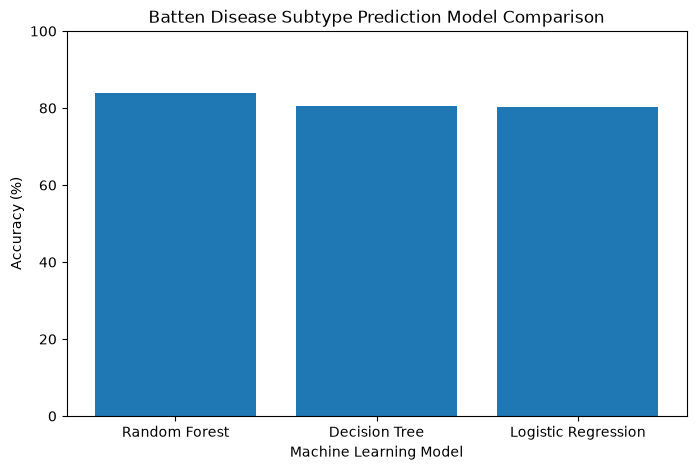

In [61]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["Accuracy (%)"]
)

plt.xlabel("Machine Learning Model")

plt.ylabel("Accuracy (%)")

plt.title("Batten Disease Subtype Prediction Model Comparison")

plt.ylim(0, 100)

plt.show()

In [62]:
best_model_name = model_results.iloc[0]["Model"]

best_accuracy = model_results.iloc[0]["Accuracy (%)"]

print(
    "Best Model:",
    best_model_name
)

print(
    "Best Accuracy:",
    best_accuracy,
    "%"
)

Best Model: Random Forest
Best Accuracy: 83.81 %


In [63]:
import joblib
import os


os.makedirs(
    "../models",
    exist_ok=True
)


model_mapping = {
    
    "Random Forest": random_forest_model,
    
    "Decision Tree": decision_tree_model,
    
    "Logistic Regression": logistic_regression_model
}


best_model = model_mapping[
    best_model_name
]


joblib.dump(
    
    best_model,
    
    "../models/batten_disease_best_model.pkl"
)


print(
    "Best model saved successfully!"
)

print(
    "Location: ../models/batten_disease_best_model.pkl"
)

Best model saved successfully!
Location: ../models/batten_disease_best_model.pkl


In [64]:
loaded_model = joblib.load(
    "../models/batten_disease_best_model.pkl"
)

print(
    "Saved model loaded successfully!"
)

Saved model loaded successfully!


In [65]:
test_prediction = loaded_model.predict(
    X_test.head(5)
)

print(
    "Sample Predictions:"
)

print(test_prediction)


print(
    "\nActual Values:"
)

print(
    y_test.head(5).values
)

Sample Predictions:
['CLN2' 'CLN3' 'CLN3' 'CLN1' 'CLN3']

Actual Values:
<StringArray>
['CLN2', 'CLN3', 'CLN2', 'CLN1', 'CLN2']
Length: 5, dtype: str


In [66]:
os.makedirs(
    "../results",
    exist_ok=True
)


model_results.to_csv(
    
    "../results/model_comparison.csv",
    
    index=False
)


print(
    "Model comparison results saved successfully!"
)

Model comparison results saved successfully!


In [3]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\Users\Adithya\OneDrive\Desktop\Batten_Disease_Prediction_Using_AI\notebooks


In [4]:
import os

print("\nCurrent directory files/folders:")
print(os.listdir())

print("\nParent directory files/folders:")
print(os.listdir(".."))


Current directory files/folders:
['01_data_exploration.ipynb', '02_combine_and_prepare_dataset.ipynb', '02_preprocessing.ipynb', '03_data_augmentation.ipynb', '04_model_training.ipynb', '05_model_evaluation.ipynb']

Parent directory files/folders:
['.git', '.gitignore', '.pytest_cache', 'app', 'data', 'docs', 'LICENSE', 'models', 'notebooks', 'README.md', 'requirements.txt', 'results', 'run.py', 'src', 'tests', 'venv']


In [5]:
model_folder = "../models"

if os.path.exists(model_folder):
    print("\nModels folder found!")
    print(os.listdir(model_folder))
else:
    print("\nModels folder NOT found at:", model_folder)


Models folder found!
['.gitkeep', 'batten_disease_best_model.pkl', 'README.md']


In [6]:
import joblib

random_forest_model = joblib.load(
    "../models/batten_disease_best_model.pkl"
)

print("Best model loaded successfully!")
print(random_forest_model)

Best model loaded successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Phenotype', 'Histology',
                                                   'Country_of_origin'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])


In [7]:
import os

print("FILES INSIDE data/processed:\n")

for file in os.listdir("../data/processed"):
    print(file)

FILES INSIDE data/processed:

batten_combined_dataset.csv
cln1_processed.csv
cln2_processed.csv
cln3_processed.csv
README.md


In [8]:
import pandas as pd

# Load final combined dataset
df = pd.read_csv("../data/processed/batten_combined_dataset.csv")

print("Dataset Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (1807, 7)

Columns:
0: Phenotype
1: Age_at_onset
2: Histology
3: Country_of_origin
4: Mutation_ID
5: Allele
6: Disease_Subtype

First 5 rows:


,Phenotype,Age_at_onset,Histology,Country_of_origin,Mutation_ID,Allele,Disease_Subtype
0,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1
1,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1
2,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1
3,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1
4,infantile,NaN,NaN,Finland,cln1.001,p.Arg122Trp,CLN1


In [9]:
print("\nPossible target-related columns:")

for col in df.columns:
    if any(word in col.lower() for word in [
        "target",
        "label",
        "disease",
        "batten",
        "class"
    ]):
        print(col)


Possible target-related columns:
Disease_Subtype


In [10]:
import joblib

MODEL_PATH = "../models/batten_disease_best_model.pkl"

model = joblib.load(MODEL_PATH)

print("SUCCESS: Best Batten Disease model loaded!")
print(type(model))

SUCCESS: Best Batten Disease model loaded!
<class 'sklearn.pipeline.Pipeline'>


In [11]:
print("MODEL INPUT INFORMATION")

try:
    print("\nFeature names expected by the model:")
    print(model.feature_names_in_)
except:
    print("\nThe model does not directly expose feature_names_in_.")
    print("Checking pipeline:")
    print(model)

MODEL INPUT INFORMATION

Feature names expected by the model:
['Phenotype' 'Age_at_onset' 'Histology' 'Country_of_origin']
